# 01.2 — Fetch Rohemeeter Biodiversity Scores

Queries the [Rohemeeter](https://shiny.botany.ut.ee/rohemeeter/) app to get
biodiversity scores at 100m resolution for the grid.

- Queries every 200m within each 1km cell (5x5 = 25 points per cell)
- Rate-limited, saves progress — safe to interrupt and resume
- Aggregates to 1km cell level

### Setup (one-time)

```bash
uv add playwright
uv run playwright install chromium
```

### Why subprocess?

Playwright doesn't work directly inside Jupyter (event loop conflict).  
The fetcher runs as a separate script; this notebook launches it and visualizes results.

In [1]:
import sys
sys.path.insert(0, '../src')

import json
import subprocess
from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CARBON_DIR = Path("../data/processed/carbon_v1_5")
PROGRESS_PATH = CARBON_DIR / "rohemeeter_progress.json"
OUTPUT_AGG = CARBON_DIR / "rohemeeter_scores.parquet"
OUTPUT_RAW = CARBON_DIR / "rohemeeter_scores_raw.parquet"
GRID_PATH = CARBON_DIR / "grid.gpkg"

## Check status

In [2]:
grid = gpd.read_file(GRID_PATH)
n_cells = len(grid)
n_points = n_cells * 25  # 5x5 per cell at 200m step

done = 0
if PROGRESS_PATH.exists():
    with open(PROGRESS_PATH) as f:
        done = len(json.load(f))

print(f"Grid: {n_cells} cells")
print(f"Total query points: {n_points}")
print(f"Already fetched: {done}")
print(f"Remaining: {n_points - done}")
print(f"ETA at 1.5s delay: ~{(n_points - done) * 1.0 / 3600:.1f} hours")

Grid: 2806 cells
Total query points: 70150
Already fetched: 62600
Remaining: 7550
ETA at 1.5s delay: ~2.1 hours


## Run fetcher

Launches the fetch script as a subprocess. Interrupt the kernel to stop — progress is saved.

Alternatively run directly in terminal:
```bash
uv run python src/carbon_dataset/09_fetch_rohemeeter.py --delay 1.5
```

In [ ]:
# Launch the fetcher (streams output live)
# Adjust --delay as needed (lower = faster but more server load)
PROJECT_ROOT = Path("__file__").resolve().parent.parent  # notebooks -> project root
# More reliable: use the grid path to find project root
PROJECT_ROOT = GRID_PATH.resolve().parents[3]
SCRIPT = PROJECT_ROOT / "src" / "carbon_dataset" / "09_fetch_rohemeeter.py"

proc = subprocess.Popen(
    [sys.executable, "-u", str(SCRIPT), "--delay", "0.0"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    cwd=str(PROJECT_ROOT),
)

try:
    for line in proc.stdout:
        print(line, end="")
except KeyboardInterrupt:
    proc.terminate()
    print("\nStopped. Progress saved — re-run to continue.")

proc.wait()

Skipping 278 water-dominated cells
Skipped 278 water cells, querying 63200 points
Total: 63200 points | Done: 55475 | Remaining: 7725
ETA: ~0.0 hours at 0.0s delay
  [saved 55485 points]
  [saved 55500 points]
  55525/63200 (87.9%) | valid: 55503 | ETA: 0.0h
  [saved 55525 points]
  [saved 55550 points]
  55575/63200 (87.9%) | valid: 55553 | ETA: 0.0h
  [saved 55575 points]
  [saved 55600 points]
  55625/63200 (88.0%) | valid: 55603 | ETA: 0.0h
  [saved 55625 points]
  [saved 55650 points]
  55675/63200 (88.1%) | valid: 55653 | ETA: 0.0h
  [saved 55675 points]
  [saved 55700 points]
  55725/63200 (88.2%) | valid: 55703 | ETA: 0.0h
  [saved 55725 points]
  [saved 55750 points]
  55775/63200 (88.3%) | valid: 55753 | ETA: 0.0h
  [saved 55775 points]
  [saved 55800 points]
  55825/63200 (88.3%) | valid: 55803 | ETA: 0.0h
  [saved 55825 points]
  [saved 55850 points]
  55875/63200 (88.4%) | valid: 55853 | ETA: 0.0h
  [saved 55875 points]
  [saved 55900 points]
  55925/63200 (88.5%) | valid:

## Export (if not already done)

In [6]:
# Export progress to parquet (in case you stopped the fetcher mid-run)
if PROGRESS_PATH.exists() and not OUTPUT_AGG.exists():
    PROJECT_ROOT = GRID_PATH.resolve().parents[3]
    SCRIPT = PROJECT_ROOT / "src" / "carbon_dataset" / "09_fetch_rohemeeter.py"
    subprocess.run(
        [sys.executable, str(SCRIPT), "--export-only"],
        cwd=str(PROJECT_ROOT),
    )

if OUTPUT_AGG.exists():
    agg = pd.read_parquet(OUTPUT_AGG)
    print(f"Aggregated scores: {len(agg)} cells")
    agg.describe().round(2)
else:
    print("No aggregated data yet. Run the fetcher first.")

Aggregated scores: 2504 cells


## Visualize

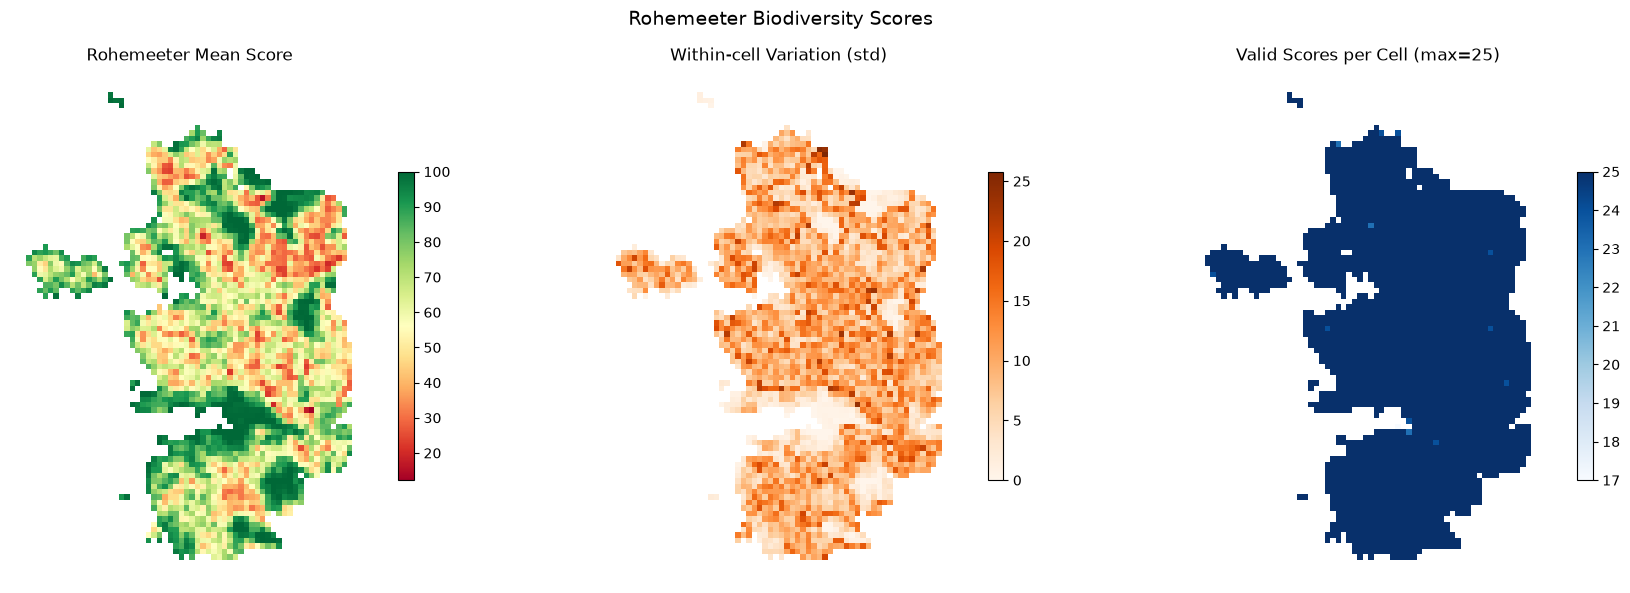

In [7]:
if OUTPUT_AGG.exists():
    from estonia_landuse.data.constants import CRS_ESTONIAN

    agg = pd.read_parquet(OUTPUT_AGG)
    gdf_scores = grid[["cell_id", "geometry"]].merge(agg, on="cell_id")
    gdf_scores = gpd.GeoDataFrame(gdf_scores, geometry="geometry", crs=CRS_ESTONIAN)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    gdf_scores.plot(column="rohemeeter_mean", ax=axes[0], legend=True, cmap="RdYlGn",
                    legend_kwds={"shrink": 0.6})
    axes[0].set_title("Rohemeeter Mean Score")
    axes[0].set_axis_off()

    gdf_scores.plot(column="rohemeeter_std", ax=axes[1], legend=True, cmap="Oranges",
                    legend_kwds={"shrink": 0.6})
    axes[1].set_title("Within-cell Variation (std)")
    axes[1].set_axis_off()

    gdf_scores.plot(column="rohemeeter_valid_count", ax=axes[2], legend=True, cmap="Blues",
                    legend_kwds={"shrink": 0.6})
    axes[2].set_title("Valid Scores per Cell (max=25)")
    axes[2].set_axis_off()

    plt.suptitle("Rohemeeter Biodiversity Scores", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize yet.")